In [1]:
# Importing important libraries
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from keras.preprocessing.sequence import TimeseriesGenerator


In [3]:
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()
data = pd.read_csv(io.StringIO(uploaded['US Wheat Futures Historical Data.csv'].decode('utf-8')))

Saving US Wheat Futures Historical Data.csv to US Wheat Futures Historical Data.csv


In [4]:
# Changing the format of the 'Date'column from object to datetime format
data['Date']=pd.to_datetime(data['Date'], infer_datetime_format=True)

In [5]:
# Converting "Price", "Open", "High", "Low", "Vol." columns to float datatype
data['Price'] = data['Price'].str.replace(',', '').astype(float)
data['Open'] = data['Open'].str.replace(',', '').astype(float)
data['High'] = data['High'].str.replace(',', '').astype(float)
data['Low'] = data['Low'].str.replace(',', '').astype(float)
data['Vol.'] = data['Vol.'].str.replace('K', '').astype(float) * 1000.
print(data.dtypes)

Date        datetime64[ns]
Price              float64
Open               float64
High               float64
Low                float64
Vol.               float64
Change %            object
dtype: object


In [6]:
# Drop the columns you don't need
data = data.drop(["Change %"], axis=1)

In [7]:
# fill missing values with mean of the column
data = data.fillna(data.mean())

# Check for null values in each column again
null_counts = data.isnull().sum()

# Print the number of null values in each column
print(null_counts)

Date     0
Price    0
Open     0
High     0
Low      0
Vol.     0
dtype: int64


<ipython-input-7-4e933ffb9d75>:2: FutureWarning: DataFrame.mean and DataFrame.median with numeric_only=None will include datetime64 and datetime64tz columns in a future version.
  data = data.fillna(data.mean())


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1087 entries, 0 to 1086
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1087 non-null   datetime64[ns]
 1   Price   1087 non-null   float64       
 2   Open    1087 non-null   float64       
 3   High    1087 non-null   float64       
 4   Low     1087 non-null   float64       
 5   Vol.    1087 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 51.1 KB


array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>], dtype=object)

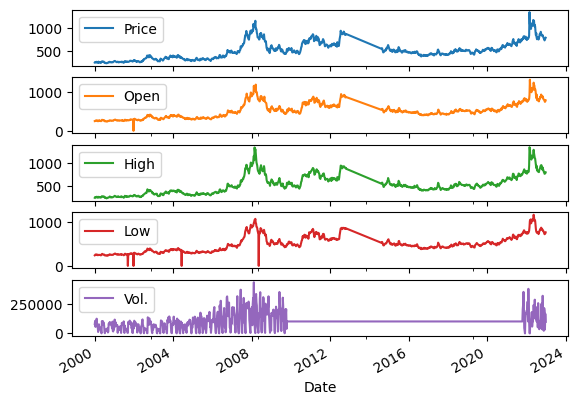

In [9]:
# Checking the correlation of each attribute with the date column
data.set_index('Date')[['Price','Open','High','Low', 'Vol.']].plot(subplots=True)

In [10]:
# Created a new dataframe which has all the columns
data_input=data[["Price",'Open','High','Low','Vol.']]
data_input

,Price,Open,High,Low,Vol.
0,792.00,781.25,799.00,765.50,97480.0
1,776.00,755.00,778.00,738.75,165670.0
2,753.50,742.50,772.00,737.60,32610.0
3,734.25,763.25,768.00,723.50,189690.0
4,761.00,793.25,799.25,755.75,213750.0
...,...,...,...,...,...
1082,257.00,258.25,260.00,249.00,75080.0
1083,259.75,265.50,269.00,256.50,89300.0
1084,264.25,261.50,267.00,261.00,55090.0
1085,265.00,251.25,267.75,248.75,105880.0


In [11]:
data_input.describe()

,Price,Open,High,Low,Vol.
count,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000
mean,510.476559,510.985216,529.382631,492.447792,100985.661376
std,192.748542,194.404552,205.563651,184.894417,57839.571027
min,236.750000,0.000000,239.750000,0.000000,120.000000
25%,356.500000,355.250000,366.500000,344.500000,79630.000000
50%,486.130000,486.380000,501.000000,471.250000,100985.661376
75%,611.750000,611.440000,634.575000,592.190000,100985.661376
max,1348.000000,1311.250000,1340.000000,1168.000000,431570.000000


In [12]:
# Standardisation of the dataset to have a standard mean so that the gradience converges faster
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data_input)
data_scaled

array([[0.49966254, 0.59580553, 0.50829357, 0.65539384, 0.22565767],
       [0.48526434, 0.57578646, 0.489207  , 0.63249144, 0.38370611],
       [0.46501687, 0.56625357, 0.48375369, 0.63150685, 0.07530421],
       ...,
       [0.02474691, 0.19942803, 0.0247671 , 0.2234589 , 0.12740758],
       [0.02542182, 0.19161106, 0.02544876, 0.21297089, 0.2451269 ],
       [0.01349831, 0.18989514, 0.01113383, 0.20633562, 0.18389153]])

In [13]:
from pandas.core.tools.datetimes import YearMonthDayDict
# Extracting the target variable 
X=data_scaled #attributes include all the columns including the target
y=data_scaled[:,0] #target only the first column = price

In [14]:
# Taking two weeks data points to predict the third, hence length=2. 
TimeseriesGenerator(X, y, length=2, sampling_rate=1, batch_size=1)[0]

(array([[[0.49966254, 0.59580553, 0.50829357, 0.65539384, 0.22565767],
         [0.48526434, 0.57578646, 0.489207  , 0.63249144, 0.38370611]]]),
 array([0.46501687]))

In [15]:
# Splitting the dataset in 80% train and 0.2% test dataset. 
# Shuffle=False because its a time series data
# x_train, x_test, y_train, y_test= train_test_split(features, target, test_size=0.2, random_state=42, shuffle=False)

In [16]:
# Addition
# Select the rows for the training set (2000-2019)
x_train = X[data['Date'].dt.year.between(2000, 2019)]
y_train = y[data['Date'].dt.year.between(2000, 2019)]

# Select the rows for the test set (2020-2022)
x_test = X[data['Date'].dt.year.between(2020, 2022)]
y_test = y[data['Date'].dt.year.between(2020, 2022)]

In [17]:
x_train.shape, x_test.shape

((931, 5), (156, 5))

In [18]:
# Define TimeSeries Generator
win_length=4 #weekly dataset, so one month we have 4 datapoints
batch_size=16
num_features=5
train_generator= TimeseriesGenerator(x_train, y_train, length=win_length, sampling_rate=1, batch_size=batch_size)
test_generator= TimeseriesGenerator(x_test, y_test, length=win_length, sampling_rate=1, batch_size=batch_size)

In [19]:
train_generator[0] #32 observation cause of batch_size and each having window length of 4

(array([[[0.28649719, 0.42621926, 0.29777778, 0.4722774 , 0.23378297],
         [0.28853093, 0.41477979, 0.29187003, 0.46114726, 0.23378297],
         [0.27524859, 0.4049571 , 0.28823449, 0.45386986, 0.23378297],
         [0.26659168, 0.40009152, 0.26960236, 0.44210616, 0.23378297]],
 
        [[0.28853093, 0.41477979, 0.29187003, 0.46114726, 0.23378297],
         [0.27524859, 0.4049571 , 0.28823449, 0.45386986, 0.23378297],
         [0.26659168, 0.40009152, 0.26960236, 0.44210616, 0.23378297],
         [0.2591676 , 0.41363584, 0.27618269, 0.44445205, 0.23378297]],
 
        [[0.27524859, 0.4049571 , 0.28823449, 0.45386986, 0.23378297],
         [0.26659168, 0.40009152, 0.26960236, 0.44210616, 0.23378297],
         [0.2591676 , 0.41363584, 0.27618269, 0.44445205, 0.23378297],
         [0.27479865, 0.39466158, 0.27823676, 0.44306507, 0.23378297]],
 
        [[0.26659168, 0.40009152, 0.26960236, 0.44210616, 0.23378297],
         [0.2591676 , 0.41363584, 0.27618269, 0.44445205, 0.23378297

In [20]:
# LSTM model architecture
from tensorflow.keras import regularizers

# LSTM model architecture
model = tf.keras.Sequential()
model.add(tf.keras.layers.LSTM(128, input_shape=(win_length, num_features), return_sequences=True, kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01)))
model.add(tf.keras.layers.LeakyReLU(alpha=0.5)) # LeakyReLU activation function
model.add(tf.keras.layers.LSTM(128, return_sequences=True, kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01)))
model.add(tf.keras.layers.LeakyReLU(alpha=0.5))
model.add(tf.keras.layers.Dropout(0.5))  # Increased dropout rate for stronger regularization
model.add(tf.keras.layers.LSTM(128, return_sequences=False, kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01)))
model.add(tf.keras.layers.Dropout(0.5))  # Increased dropout rate for stronger regularization
model.add(tf.keras.layers.Dense(1))

In [21]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 4, 128)            68608     
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 4, 128)            0         
                                                                 
 lstm_1 (LSTM)               (None, 4, 128)            131584    
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 4, 128)            0         
                                                                 
 dropout (Dropout)           (None, 4, 128)            0         
                                                                 
 lstm_2 (LSTM)               (None, 128)               131584    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0

In [22]:
# Defining the model
# early_stopping=tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, mode='min')

model.compile(loss=tf.losses.MeanSquaredError(), optimizer=tf.optimizers.Nadam(), metrics=[tf.metrics.MeanAbsoluteError()])

history=model.fit_generator(train_generator, epochs= 100, validation_data=test_generator, shuffle=False) #, callbacks=[early_stopping])

Epoch 1/100


<ipython-input-22-23af3bb68b41>:6: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history=model.fit_generator(train_generator, epochs= 100, validation_data=test_generator, shuffle=False) #, callbacks=[early_stopping])


58/58 [==============================] - 6s 28ms/step - loss: 40.2234 - mean_absolute_error: 0.1165 - val_loss: 14.6210 - val_mean_absolute_error: 0.3888
Epoch 2/100
58/58 [==============================] - 1s 19ms/step - loss: 4.2570 - mean_absolute_error: 0.1499 - val_loss: 0.3098 - val_mean_absolute_error: 0.3636
Epoch 3/100
58/58 [==============================] - 1s 17ms/step - loss: 0.1593 - mean_absolute_error: 0.1744 - val_loss: 0.2346 - val_mean_absolute_error: 0.3064
Epoch 4/100
58/58 [==============================] - 1s 14ms/step - loss: 0.1516 - mean_absolute_error: 0.1601 - val_loss: 0.2242 - val_mean_absolute_error: 0.2887
Epoch 5/100
58/58 [==============================] - 1s 14ms/step - loss: 0.1501 - mean_absolute_error: 0.1527 - val_loss: 0.2169 - val_mean_absolute_error: 0.2747
Epoch 6/100
58/58 [==============================] - 1s 14ms/step - loss: 0.1493 - mean_absolute_error: 0.1480 - val_loss: 0.2124 - val_mean_absolute_error: 0.2662
Epoch 7/100
58/58 [=======

In [23]:
# Checking on models on the test part
model.evaluate_generator(test_generator)

<ipython-input-23-fb2167925083>:2: UserWarning: `Model.evaluate_generator` is deprecated and will be removed in a future version. Please use `Model.evaluate`, which supports generators.
  model.evaluate_generator(test_generator)


[0.3112657368183136, 0.4021728038787842]

In [24]:
predictions=model.predict_generator(test_generator)

<ipython-input-24-6ca49477046f>:1: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  predictions=model.predict_generator(test_generator)


In [25]:
# Test data had 156 datapoints and 4 win_length hence the prediction shape is 152
predictions.shape[0]

152

In [26]:
predictions

array([[0.03034639],
       [0.03034638],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.03034639],
       [0.030

In [27]:
x_test, y_test

(array([[4.99662542e-01, 5.95805529e-01, 5.08293570e-01, 6.55393836e-01,
         2.25657666e-01],
        [4.85264342e-01, 5.75786463e-01, 4.89206998e-01, 6.32491438e-01,
         3.83706107e-01],
        [4.65016873e-01, 5.66253575e-01, 4.83753692e-01, 6.31506849e-01,
         7.53042067e-02],
        [4.47694038e-01, 5.82078170e-01, 4.80118155e-01, 6.19434932e-01,
         4.39378839e-01],
        [4.71766029e-01, 6.04957102e-01, 5.08520791e-01, 6.47046233e-01,
         4.95144281e-01],
        [4.84814398e-01, 6.10486177e-01, 5.17155192e-01, 6.60102740e-01,
         5.18715958e-02],
        [5.09786277e-01, 6.20019066e-01, 5.48284481e-01, 6.79580479e-01,
         4.80866844e-01],
        [5.19235096e-01, 6.47382269e-01, 5.67007498e-01, 6.81164384e-01,
         1.74689999e-01],
        [5.49831271e-01, 6.74547188e-01, 6.03726426e-01, 7.08690068e-01,
         7.35589292e-01],
        [5.33183352e-01, 6.50905624e-01, 5.61735969e-01, 7.04195205e-01,
         7.84100127e-02],
        [5

In [28]:
# Creating a dataframe from the x_test which include the variables accept the 1st column
x_test[:,1][win_length:]

array([0.6049571 , 0.61048618, 0.62001907, 0.64738227, 0.67454719,
       0.65090562, 0.65729647, 0.68274547, 0.7092469 , 0.6702612 ,
       0.65376549, 0.65996568, 0.61620591, 0.61830315, 0.57502383,
       0.61163012, 0.59218303, 0.62087321, 0.60019066, 0.60038132,
       0.70867493, 0.64232602, 0.71172545, 0.78703527, 0.81830315,
       0.80838894, 0.88236416, 0.90123928, 0.94127741, 0.85471878,
       0.79714013, 0.8184938 , 0.83832221, 0.80533842, 0.75462345,
       0.83584366, 0.81982841, 0.84346997, 1.        , 0.70181125,
       0.62154433, 0.61124881, 0.59180172, 0.60076263, 0.60552908,
       0.56606292, 0.58017159, 0.59027645, 0.62345091, 0.59294566,
       0.59428027, 0.6099142 , 0.63889418, 0.62640991, 0.62516683,
       0.58589133, 0.59065777, 0.57940896, 0.55996187, 0.55948141,
       0.57549666, 0.55167207, 0.53975214, 0.52564347, 0.5521449 ,
       0.5620591 , 0.54384747, 0.5815062 , 0.54956721, 0.53784557,
       0.52118208, 0.53641945, 0.46872831, 0.47378456, 0.48713

In [29]:
# Make prediction on the the previous dataframe
data.pred=pd.concat([pd.DataFrame(predictions), pd.DataFrame(x_test[:,1:][win_length:])], axis=1)
data.pred # Scaled values

<ipython-input-29-d0c09e8effeb>:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  data.pred=pd.concat([pd.DataFrame(predictions), pd.DataFrame(x_test[:,1:][win_length:])], axis=1)


,0,0,1,2,3
0,0.030346,0.604957,0.508521,0.647046,0.495144
1,0.030346,0.610486,0.517155,0.660103,0.051872
2,0.030346,0.620019,0.548284,0.679580,0.480867
3,0.030346,0.647382,0.567007,0.681164,0.174690
4,0.030346,0.674547,0.603726,0.708690,0.735589
...,...,...,...,...,...
147,0.030346,0.420301,0.296069,0.467894,0.233783
148,0.030346,0.437277,0.306176,0.471747,0.233783
149,0.030346,0.435554,0.320500,0.485445,0.233783
150,0.030346,0.429453,0.307994,0.478271,0.233783


In [30]:
# Perform the reverse transform on the above scaled dataset
rev_trans=scaler.inverse_transform(data.pred)
rev_trans # Hence values are reversed to get the actual value

array([[2.70472430e+02, 7.93250000e+02, 7.99250000e+02, 7.55750000e+02,
        2.13750000e+05],
       [2.70472413e+02, 8.00500000e+02, 8.08750000e+02, 7.71000000e+02,
        2.25000000e+04],
       [2.70472430e+02, 8.13000000e+02, 8.43000000e+02, 7.93750000e+02,
        2.07590000e+05],
       [2.70472430e+02, 8.48880000e+02, 8.63600000e+02, 7.95600000e+02,
        7.54900000e+04],
       [2.70472430e+02, 8.84500000e+02, 9.04000000e+02, 8.27750000e+02,
        3.17490000e+05],
       [2.70472430e+02, 8.53500000e+02, 8.57800000e+02, 8.22500000e+02,
        3.39500000e+04],
       [2.70472430e+02, 8.61880000e+02, 8.77500000e+02, 8.32880000e+02,
        4.19100000e+04],
       [2.70472430e+02, 8.95250000e+02, 9.49750000e+02, 8.57250000e+02,
        2.50710000e+05],
       [2.70472430e+02, 9.30000000e+02, 9.38750000e+02, 8.72500000e+02,
        1.89300000e+05],
       [2.70472430e+02, 8.78880000e+02, 9.45750000e+02, 8.54380000e+02,
        7.81400000e+04],
       [2.70472430e+02, 8.5725

In [31]:
# Making final prediction. Count also matches the test dataframe
data_final=data_input[predictions.shape[0]*-1:]
data_final, data_final.count()

(       Price    Open    High     Low      Vol.
 935   373.00  372.50  383.00  371.50   40080.0
 936   373.75  389.75  390.75  367.75   77580.0
 937   389.75  382.50  398.50  369.00  101770.0
 938   382.50  412.25  416.00  382.00   92650.0
 939   413.50  409.50  419.00  397.00   92550.0
 ...      ...     ...     ...     ...       ...
 1082  257.00  258.25  260.00  249.00   75080.0
 1083  259.75  265.50  269.00  256.50   89300.0
 1084  264.25  261.50  267.00  261.00   55090.0
 1085  265.00  251.25  267.75  248.75  105880.0
 1086  251.75  249.00  252.00  241.00   79460.0
 
 [152 rows x 5 columns],
 Price    152
 Open     152
 High     152
 Low      152
 Vol.     152
 dtype: int64)

In [32]:
# Adding the reversed predicted column in the original dataframe
data_final['Price Predicted']=rev_trans[:,0]
data_final

<ipython-input-32-0ad126213f07>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_final['Price Predicted']=rev_trans[:,0]


,Price,Open,High,Low,Vol.,Price Predicted
935,373.00,372.50,383.00,371.50,40080.0,270.472430
936,373.75,389.75,390.75,367.75,77580.0,270.472413
937,389.75,382.50,398.50,369.00,101770.0,270.472430
938,382.50,412.25,416.00,382.00,92650.0,270.472430
939,413.50,409.50,419.00,397.00,92550.0,270.472430
...,...,...,...,...,...,...
1082,257.00,258.25,260.00,249.00,75080.0,270.472430
1083,259.75,265.50,269.00,256.50,89300.0,270.472430
1084,264.25,261.50,267.00,261.00,55090.0,270.472430
1085,265.00,251.25,267.75,248.75,105880.0,270.472413


<Axes: >

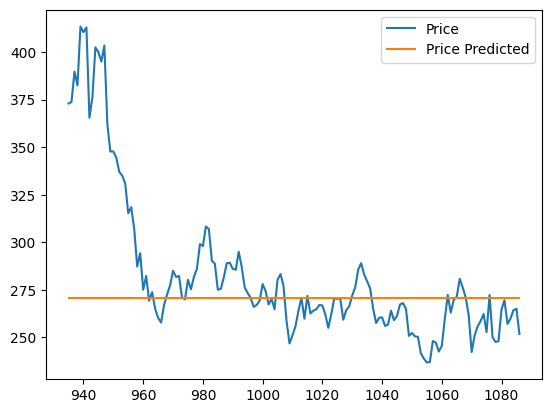

In [33]:
# Checking the prediction with the original price with the predicted price
data_final[['Price','Price Predicted']].plot()

In [34]:
!pip install dmba
from dmba import regressionSummary

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 82.0 MB/s eta 0:00:00
no display found. Using non-interactive Agg backend


In [35]:
regressionSummary(data_final.Price, data_final['Price Predicted'])


Regression statistics

                      Mean Error (ME) : 12.6592
       Root Mean Squared Error (RMSE) : 41.8746
            Mean Absolute Error (MAE) : 24.3066
          Mean Percentage Error (MPE) : 2.9173
Mean Absolute Percentage Error (MAPE) : 7.5401
